In [1]:
!pip -q install datasets huggingface_hub duckdb pandas fsspec

In [2]:
from huggingface_hub import login

login()

In [3]:
from huggingface_hub import hf_hub_download

In [4]:
sample_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance_sample.parquet",
    repo_type="dataset"
)

print(sample_path)

fact_content_daily_performance_sample.pa(…): reconstructing file:   0%|          |  0.00B /  145MB            

fact_content_daily_performance_sample.pa(…): downloading bytes:           |  0.00B            

/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance_sample.parquet


In [5]:
import duckdb

con = duckdb.connect()

df = con.sql(f"""
SELECT *
FROM read_parquet('{sample_path}')
""").df()

print(df.shape)
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(11694072, 31)


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-06-01,client_3ffa76342f366962,content_1a6296faee432dae,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
1,2026-06-01,client_3ffa76342f366962,content_73f21e612565035a,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
2,2026-06-01,client_3ffa76342f366962,content_5a5be514ff559598,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
3,2026-06-01,client_3ffa76342f366962,content_05b377d0c8a5cfd8,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06
4,2026-06-01,client_3ffa76342f366962,content_dc34c661d63e55a9,True,True,False,False,0,0,0,...,0,0,0,0,0,0,0,0,0,2026-06


In [6]:
content_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="dim_content.parquet",
    repo_type="dataset"
)

clients_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="dim_clients.parquet",
    repo_type="dataset"
)

dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

dim_clients.parquet: reconstructing file:   0%|          |  0.00B / 3.38kB            

dim_clients.parquet: downloading bytes:           |  0.00B            

In [7]:
content = con.sql(f"""
SELECT *
FROM read_parquet('{content_path}')
""").df()

clients = con.sql(f"""
SELECT *
FROM read_parquet('{clients_path}')
""").df()

print(df.shape)
print(content.shape)
print(clients.shape)

(11694072, 31)
(519606, 26)
(104, 9)


In [8]:
con.execute(f"""
CREATE OR REPLACE TABLE capstone AS

SELECT
    f.*,

    c.keyword_char_count,
    c.keyword_token_count,
    c.url_char_count,
    c.search_volume,
    c.main_intent,
    c.content_type,
    c.backlinks,
    c.word_count,
    c.char_count,

    cl.has_gsc_access,
    cl.has_ga4_access

FROM read_parquet('{sample_path}') f

LEFT JOIN read_parquet('{content_path}') c
ON f.client_hash_id = c.client_hash_id
AND f.content_hash_id = c.content_hash_id

LEFT JOIN read_parquet('{clients_path}') cl
ON f.client_hash_id = cl.client_hash_id;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
con.sql("""
SELECT COUNT(*)
FROM capstone
""").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     11694072 │
└──────────────┘



In [10]:
con.sql("""
DESCRIBE capstone
""").show()

┌─────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │ column_type │  null   │   key   │ default │  extra  │
│       varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ report_date         │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_hash_id      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ content_hash_id     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_gsc      │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_ga4      │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_available  │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_available  │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_impressions     │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_clicks          │ BIGINT      │ YES     │ NULL    │ NULL  

In [11]:
con.execute("""
CREATE OR REPLACE TABLE content_features AS

SELECT

content_hash_id,
client_hash_id,

AVG(gsc_impressions) AS avg_impressions,
AVG(gsc_clicks) AS avg_clicks,
AVG(gsc_avg_position) AS avg_position,

AVG(ga4_sessions) AS avg_sessions,
AVG(ga4_pageviews) AS avg_pageviews,
AVG(ga4_engaged_sessions) AS avg_engaged_sessions,

AVG(scroll_events) AS avg_scroll_events,
AVG(sessions_ai) AS avg_ai_sessions,

MAX(search_volume) AS search_volume,
MAX(backlinks) AS backlinks,
MAX(word_count) AS word_count,
MAX(char_count) AS char_count,
MAX(keyword_char_count) AS keyword_char_count,
MAX(keyword_token_count) AS keyword_token_count,
MAX(url_char_count) AS url_char_count,

MAX(main_intent) AS main_intent,
MAX(content_type) AS content_type

FROM capstone

GROUP BY
content_hash_id,
client_hash_id
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [12]:
con.sql("""
SELECT COUNT(*)
FROM content_features
""").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       409205 │
└──────────────┘



In [13]:
con.sql("""
SELECT *
FROM content_features
LIMIT 5
""").show()

┌──────────────────────────┬─────────────────────────┬─────────────────┬────────────┬──────────────┬──────────────┬───────────────┬──────────────────────┬───────────────────┬─────────────────┬───────────────┬───────────┬────────────┬────────────┬────────────────────┬─────────────────────┬────────────────┬───────────────┬─────────────────┐
│     content_hash_id      │     client_hash_id      │ avg_impressions │ avg_clicks │ avg_position │ avg_sessions │ avg_pageviews │ avg_engaged_sessions │ avg_scroll_events │ avg_ai_sessions │ search_volume │ backlinks │ word_count │ char_count │ keyword_char_count │ keyword_token_count │ url_char_count │  main_intent  │  content_type   │
│         varchar          │         varchar         │     double      │   double   │    double    │    double    │    double     │        double        │      double       │     double      │     int64     │   int64   │   int64    │   int64    │       int64        │        int64        │     int64      │    varchar 

In [14]:
con.execute("""
CREATE OR REPLACE TABLE ml_dataset AS

SELECT *,

CASE
    WHEN
        avg_impressions > 100
        AND avg_clicks / NULLIF(avg_impressions,0) < 0.02
        AND avg_position > 15
    THEN 1
    ELSE 0
END AS needs_refresh

FROM content_features
""")

In [15]:
con.sql("""
SELECT
needs_refresh,
COUNT(*)
FROM ml_dataset
GROUP BY needs_refresh
""").show()

┌───────────────┬──────────────┐
│ needs_refresh │ count_star() │
│     int32     │    int64     │
├───────────────┼──────────────┤
│             0 │       407476 │
│             1 │         1729 │
└───────────────┴──────────────┘



In [16]:
ml_df = con.sql("""
SELECT *
FROM ml_dataset
""").df()

In [17]:
features = [
    "avg_impressions",
    "avg_clicks",
    "avg_position",
    "avg_sessions",
    "avg_pageviews",
    "avg_engaged_sessions",
    "avg_scroll_events",
    "avg_ai_sessions",
    "search_volume",
    "backlinks",
    "word_count",
    "char_count",
    "keyword_char_count",
    "keyword_token_count",
    "url_char_count"
]

X = ml_df[features]
y = ml_df["needs_refresh"]

In [18]:
X = X.fillna(0)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [21]:
pred = model.predict(X_test)

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy : 0.9999633435564081
Precision: 1.0
Recall   : 0.9913294797687862
F1 Score : 0.9956458635703919
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     81495
           1       1.00      0.99      1.00       346

    accuracy                           1.00     81841
   macro avg       1.00      1.00      1.00     81841
weighted avg       1.00      1.00      1.00     81841



In [23]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

                 Feature  Importance
0        avg_impressions    0.339051
2           avg_position    0.177515
1             avg_clicks    0.160409
3           avg_sessions    0.095184
4          avg_pageviews    0.089484
6      avg_scroll_events    0.039628
10            word_count    0.030908
5   avg_engaged_sessions    0.030900
11            char_count    0.018059
12    keyword_char_count    0.005980
14        url_char_count    0.004988
13   keyword_token_count    0.003639
8          search_volume    0.002362
9              backlinks    0.001070
7        avg_ai_sessions    0.000824


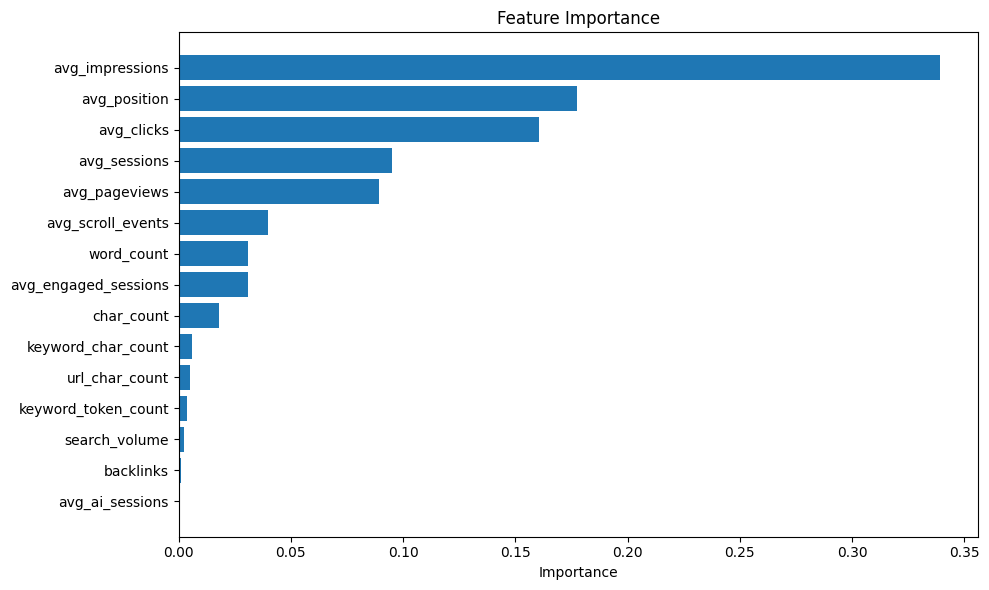

In [24]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [25]:
ml_df["refresh_probability"] = model.predict_proba(X)[:,1]

In [26]:
recommendations = ml_df[
    [
        "content_hash_id",
        "client_hash_id",
        "refresh_probability",
        "avg_impressions",
        "avg_clicks",
        "avg_position"
    ]
].sort_values(
    "refresh_probability",
    ascending=False
)

recommendations.head(20)

,content_hash_id,client_hash_id,refresh_probability,avg_impressions,avg_clicks,avg_position
303924,content_0e60e9ab0f3b4b33,client_23a62021009f63c4,1.0,477.866667,1.000000,38.444633
212119,content_f8c0566c8f017176,client_23a62021009f63c4,1.0,163.333333,0.300000,27.979297
362729,content_7db726a87343e8e8,client_23a62021009f63c4,1.0,122.933333,0.966667,15.090198
97870,content_df61affb97835ae7,client_23a62021009f63c4,1.0,199.400000,0.133333,39.490198
9716,content_91a3f1d364534690,client_23a62021009f63c4,1.0,236.066667,1.033333,18.706601
157423,content_4e98cd7d19bc6af0,client_23a62021009f63c4,1.0,219.333333,1.500000,30.212663
212123,content_0f7a4c1d26aa1acb,client_23a62021009f63c4,1.0,160.033333,0.500000,22.751407
303338,content_22a01117af6f0ecf,client_23a62021009f63c4,1.0,179.400000,0.233333,38.012013
97872,content_35317f4121eb61c0,client_23a62021009f63c4,1.0,121.166667,0.700000,18.708535
214507,content_e116392bcc5d1470,client_23a62021009f63c4,1.0,186.400000,0.633333,17.372255


In [27]:
recommendations.to_csv(
    "refresh_recommendations.csv",
    index=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)